# combine master files

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, astropy, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name==version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

In [24]:
# Install a pip package in the current Jupyter kernel
import importlib, sys, subprocess
print(f"sys.executable: {sys.executable}")

packages = "numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"**** {pkg} module is now installed.")
    else: 
        print(f"******** {pkg} module is already installed.")
%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")


sys.executable: /home/guitar79/anaconda3/envs/astro_Python_env/bin/python
******** numpy module is already installed.
******** pandas module is already installed.
******** matplotlib module is already installed.
******** scipy module is already installed.
******** astropy module is already installed.
******** photutils module is already installed.
******** ccdproc module is already installed.
******** version_information module is already installed.
The version_information extension is already loaded. To reload it, use:
  %reload_ext version_information
This notebook was generated at 2024-06-09 01:57:26 (KST = GMT+0900) 
0 Python     3.11.5 64bit [GCC 11.2.0]
1 IPython    8.20.0
2 OS         Linux 5.15.0 107 generic x86_64 with glibc2.31
3 numpy      1.26.4
4 pandas     2.2.1
5 matplotlib 3.8.4
6 scipy      1.12.0
7 astropy    6.1.0
8 photutils  1.9.0
9 ccdproc    2.4.2
10 version_information 1.0.4


### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

### import modules

In [25]:
from glob import glob
from pathlib import Path
import os
import numpy as np
import astropy.units as u
#from astropy.stats import sigma_clip
#from ccdproc import combine, ccd_process, CCDData
from astropy.io import fits
import matplotlib.pyplot as plt

import ysfitsutilpy as yfu
#import ysphotutilpy as ypu
#import ysvisutilpy as yvu

import _astro_utilities
import _Python_utilities
import _tool_visualization

"CAL-BDF" 폴더 찾기

In [26]:
#%%
BASEDIR = Path("/mnt/Rdata/OBS_data") 
DOINGDIR = Path(BASEDIR/ "2024-EXO" / "RiLA600_STX-16803_-_1bin")
DOINGDIR = Path(BASEDIR/ "2024-EXO" / "RiLA600_STX-16803_-_2bin")
#DOINGDIR = Path(BASEDIR/ "2024-EXO" / "GSON300_STF-8300M_-_1bin")

DOINGDIRs = sorted(_Python_utilities.getFullnameListOfsubDirs(DOINGDIR))
DOINGDIRs = sorted([x for x in DOINGDIR.iterdir() if x.is_dir()])
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))


DOINGDIRs = [x for x in DOINGDIRs if "CAL-BDF" in str(x)]

print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

DOINGDIRs:  [PosixPath('/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/WASP-103b_LIGHT_-_2024-06-06_-_RiLA600_STX-16803_-_2bin')]
len(DOINGDIRs):  2
DOINGDIRs:  [PosixPath('/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin')]
len(DOINGDIRs):  1


summary 만들기

In [27]:
for DOINGDIR in DOINGDIRs[:1] :
    DOINGDIR = Path(DOINGDIR)
    print("DOINGDIR", DOINGDIR)
    fits_in_dir = sorted(list(DOINGDIR.glob('*.fit*')))
    #print("fits_in_dir", fits_in_dir)
    print("len(fits_in_dir)", len(fits_in_dir))

    if len(fits_in_dir) == 0 :
        print(f"There is no fits fils in {DOINGDIR}")
        pass
    else : 
        print(f"Starting: {str(DOINGDIR.parts[-1])}")
    
        MASTERDIR = DOINGDIR / _astro_utilities.master_dir

        if not MASTERDIR.exists():
            os.makedirs("{}".format(str(MASTERDIR)))
            print("{} is created...".format(str(MASTERDIR)))

        summary = yfu.make_summary(DOINGDIR/"*.fit*")
        #print(summary)
        print("len(summary):", len(summary))
        print("summary:", summary)
        #print(summary["file"][0])

DOINGDIR /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin
len(fits_in_dir) 232
Starting: -_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin
/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys is created...
All 49 keywords (guessed from /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/-_FLAT_2X2_2024-05-16-10-44-58_0sec_RiLA600_STX-16803_-19c_2bin.fit) will be loaded.


/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key BSCALE not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/BiasDark_BIAS_-_2024-05-28-13-02-33_0sec_-_STX-16803_26c_2bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key XORGSUBF not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/BiasDark_BIAS_-_2024-05-28-13-02-33_0sec_-_STX-16803_26c_2bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key YORGSUBF not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/BiasDark_BIAS

len(summary): 232
summary:                                                   file  filesize  SIMPLE  \
0    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
1    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
2    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
3    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
4    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
..                                                 ...       ...     ...   
227  /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
228  /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
229  /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
230  /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   
231  /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...   8395200    True   

     BITPIX  NAXIS  NAXIS1  NAXIS2  BSCALE    BZERO         

### BIAS

master bias 만들기

In [28]:
if (MASTERDIR / "master_bias.fits").exists():
    print("is exist")
else :
    #bias_fits = summary[summary["IMAGETYP"] == "BIAS"]["file"]
    bias_fits = summary.loc[summary["IMAGETYP"] == "BIAS"].copy()
    bias_fits.reset_index(inplace=True)
    bias_fits = bias_fits["file"]
    print(type(bias_fits))
    print(len(bias_fits))
    print(bias_fits)

    bias_comb = yfu.group_combine(
                    bias_fits.tolist(),
                    type_key = ["IMAGETYP"],
                    type_val = ["BIAS"],
                    group_key = ["EXPTIME"],
                    fmt = "master_bias.fits",  # output file name format
                    outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                    combine = "med",
                    memlimit = 2.e+10,
                    verbose = True
                )

<class 'pandas.core.series.Series'>
20
0     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
1     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
2     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
3     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
4     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
5     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
6     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
7     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
8     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
9     /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
10    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
11    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
12    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
13    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
14    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
15    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
16    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
17    /mn

	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_bias.fits
..................................(dt = 2.237 s) 2024-06-08T16:57:37.748


화면에 디스플레이 해보기

In [29]:
import matplotlib.pyplot as plt

hdul = fits.open(MASTERDIR / "master_bias.fits")

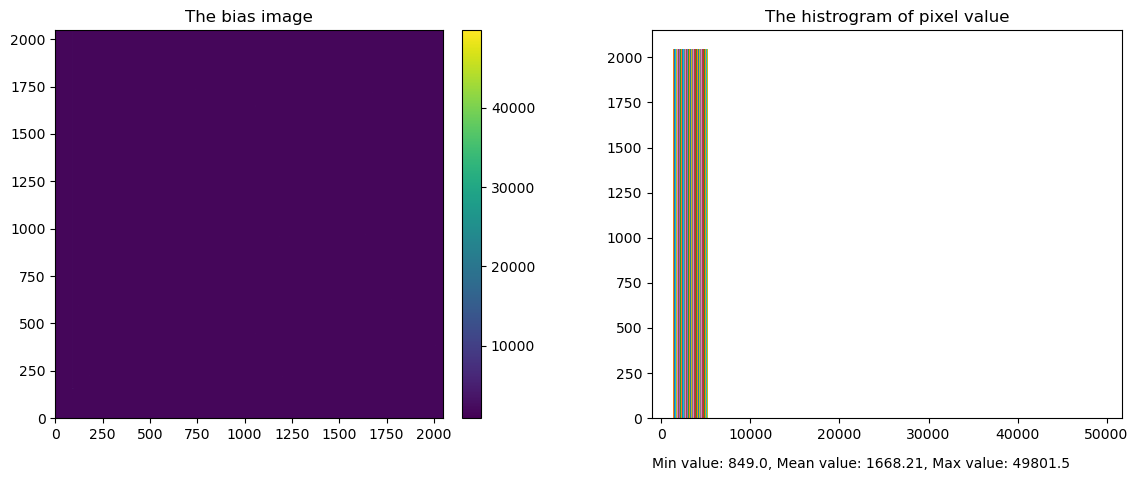

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = axs[0].imshow(hdul[0].data,
                origin='lower',
                )
im2 = axs[1].hist(hdul[0].data,
                # histtype='step',
                # 1000,
                )

axs[0].set_title('The bias image')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Max value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)

zimshow를 이용해 보자.

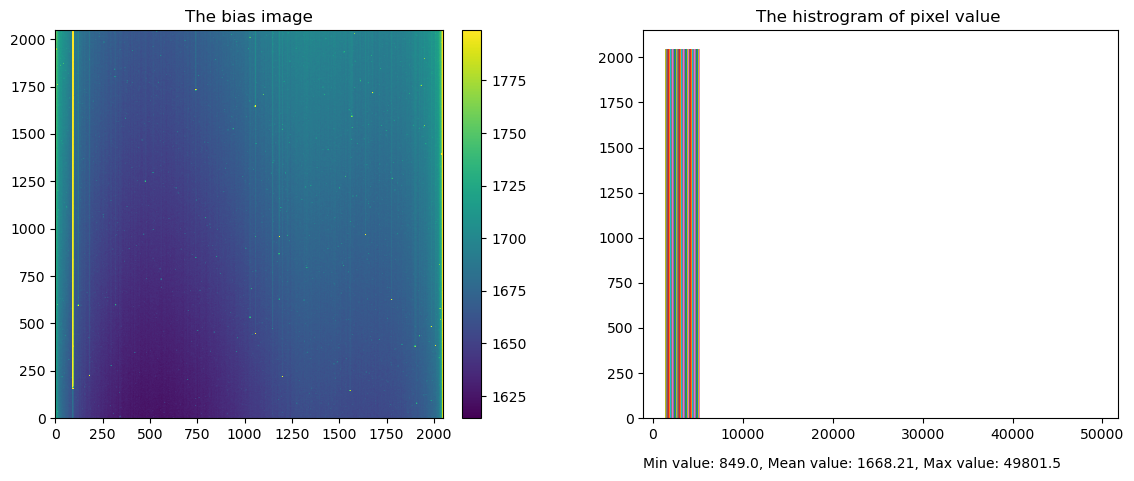

In [31]:
import numpy as np
import matplotlib.pyplot as plt

hdul = fits.open(MASTERDIR / "master_bias.fits")

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = _tool_visualization.zimshow(axs[0], 
                            hdul[0].data,
                            )
im2 = axs[1].hist(hdul[0].data,
                )

axs[0].set_title('The bias image')
axs[1].set_title('The histrogram of pixel value ')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Max value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)

3 sigma 안의 데이터만 확인해 보자.

### DARK

dark 합성

In [32]:
#dark_fits = summary[summary["IMAGETYP"] == "DARK"]["file"]
dark_fits = summary.loc[summary["IMAGETYP"] == "DARK"].copy()
dark_fits.reset_index(inplace=True)
dark_fits = dark_fits["file"]
print(type(dark_fits))
print(len(dark_fits))
print(dark_fits)
# Say dark frames have header OBJECT = "calib" && "IMAGE-TYP" = "DARK"
dark_comb = yfu.group_combine(
                dark_fits.tolist(),
                type_key = ["IMAGETYP"],
                type_val = ["DARK"],
                group_key = ["EXPTIME"],
                fmt = "master_dark_{:.0f}sec.fits",  # output file name format
                outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                combine = "med",
                memlimit = 2.e+10,
                verbose = True
            )

<class 'pandas.core.series.Series'>
140
0      /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
1      /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
2      /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
3      /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
4      /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
                             ...                        
135    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
136    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
137    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
138    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
139    /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...
Name: file, Length: 140, dtype: object
Group and combine by ['EXPTIME'] (total 7 groups)
* 30.0... (20 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_dark_30sec.fits
* 60.0... (20 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_dark_60sec.fits
* 90.0... (20 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_dark_90sec.fits
* 120.0... (20 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_dark_120sec.fits
* 150.0... (20 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_dark_150sec.fits
* 180.0... (20 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_dark_180sec.fits
* 210.0... (20 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_dark_210sec.fits
.................................(dt = 39.156 s) 2024-06-08T16:58:39.123


In [33]:
# hdul = fits.open(MASTERDIR / "master_bias.fits")

# fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

# im1 = axs[0].imshow(hdul[0].data)
# im2 = axs[1].hist(hdul[0].data 
#                     #histtype='step',
#                     #50 
#                     )

# axs[0].set_title('The dark image')
# axs[1].set_title('The histrogram of pixel value')

# plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Meax value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

# plt.colorbar(im1, fraction=0.035, pad=0.04)
# plt.tight_layout(pad=5.0)

## Flat

In [34]:
flat_fits = summary[summary["IMAGETYP"] == "FLAT"]["file"] 
# Say dark frames have header OBJECT = "calib" && "IMAGE-TYP" = "DARK"
flat_comb_norm = yfu.group_combine(
                flat_fits.tolist(),
                type_key = ["IMAGETYP"],
                type_val = ["FLAT"],
                group_key = ["FILTER"],
                fmt = "master_flat_{:s}_norm.fits",  # output file name format
                scale="med_sc", #norm
                scale_to_0th=False, #norm
                outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                combine = "med",
                memlimit = 2.e+10,
                verbose=True
            )

# Say dark frames have header OBJECT = "calib" && "IMAGE-TYP" = "DARK"
flat_comb_norm = yfu.group_combine(
                flat_fits.tolist(),
                type_key = ["IMAGETYP"],
                type_val = ["FLAT"],
                group_key = ["FILTER"],
                fmt = "master_flat_{:s}.fits",  # output file name format
                #scale="med_sc", #norm
                #scale_to_0th=False, #norm
                outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                combine = "med",
                memlimit = 2.e+10,
                verbose=True
            )

Group and combine by ['FILTER'] (total 4 groups)
* 2X2... (18 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_flat_2X2_norm.fits
* B... (18 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_flat_B_norm.fits
* R... (18 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_flat_R_norm.fits
* V... (18 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_flat_V_norm.fits
.................................(dt = 31.943 s) 2024-06-08T16:59:11.077
Group and combine by ['FILTER'] (total 4 groups)
* 2X2... (18 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_flat_2X2.fits
* B... (18 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_flat_B.fits
* R... (18 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_flat_R.fits
* V... (18 files)


	/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_2bin/master_files_ys/master_flat_V.fits
.................................(dt = 12.695 s) 2024-06-08T16:59:23.773


In [35]:
# hdul = fits.open(flat_fits[3])

# fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
# im = yvu.zimshow(axs, hdul[0].data)
# axs.set_title('The flat image')
# plt.colorbar(im, fraction=0.035, pad=0.04)
# plt.tight_layout()

In [36]:
# fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

# im1 = yvu.zimshow(axs[0], hdul[0].data)
# im2 = axs[1].hist(hdul[0].data 
#                     #histtype='step',
#                     #50 
#                     )

# axs[0].set_title('The flat image')
# axs[1].set_title('The histrogram of pixel value')

# plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

# plt.colorbar(im1, fraction=0.035, pad=0.04)
# plt.tight_layout(pad=5.0)

## Flat image

skyflat image

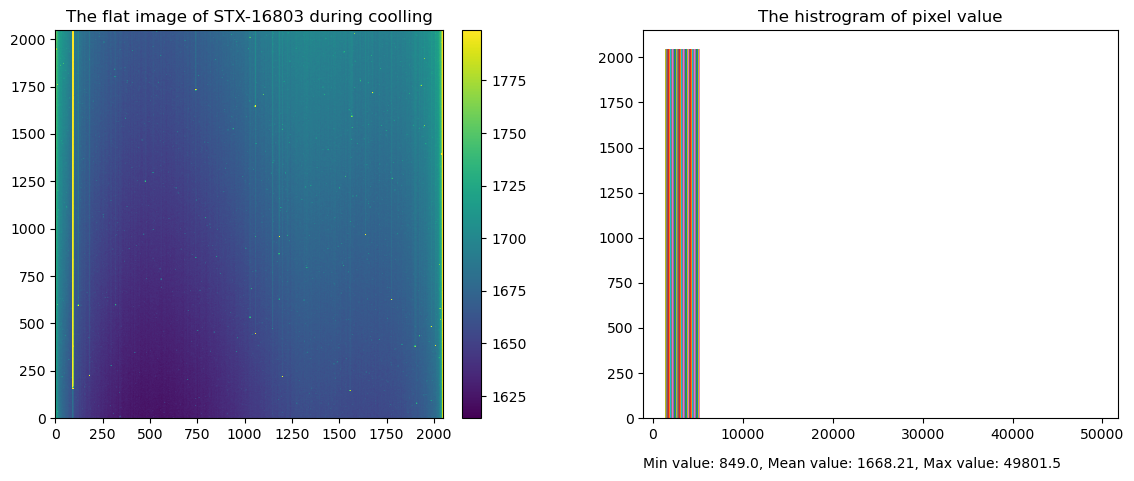

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

#im1 = yvu.zimshow(axs[0], hdul[0].data)
im1 = _tool_visualization.zimshow(axs[0], 
                               hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The flat image of STX-16803 during coolling')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Max value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)